## Problem Statement

The objective of this project is to predict student mathematics performance using demographic and educational factors such as gender, race, parental level of education, lunch type, test preparation course, reading score, and writing score.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
df = pd.read_csv("/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 8)


In [7]:
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


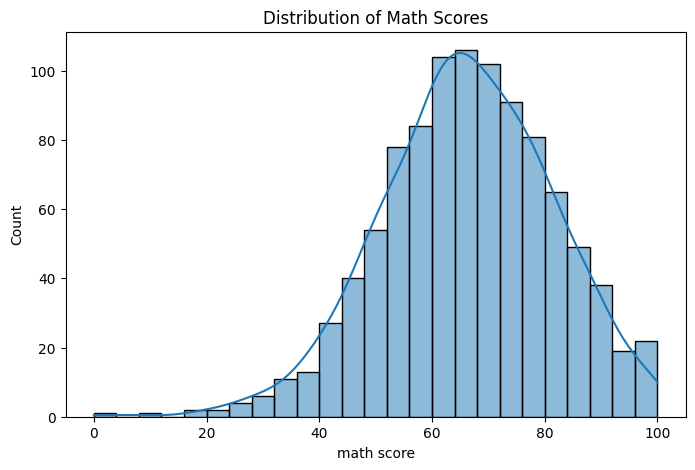

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["math score"], kde=True)
plt.title("Distribution of Math Scores")
plt.show()

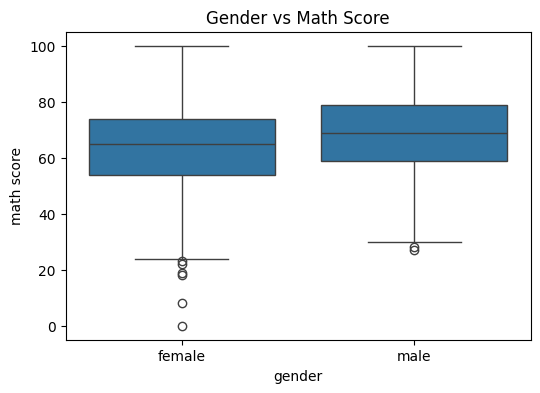

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(x="gender", y="math score", data=df)
plt.title("Gender vs Math Score")
plt.show()

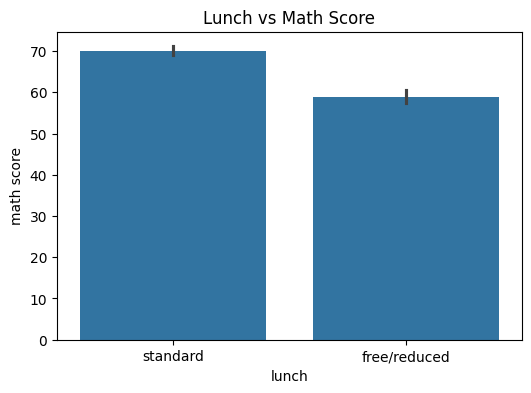

In [10]:
plt.figure(figsize=(6,4))
sns.barplot(x="lunch", y="math score", data=df)
plt.title("Lunch vs Math Score")
plt.show()

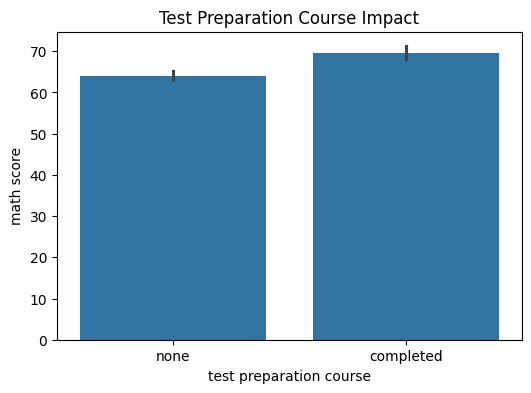

In [11]:
plt.figure(figsize=(6,4))
sns.barplot(
    x="test preparation course",
    y="math score",
    data=df
)
plt.title("Test Preparation Course Impact")
plt.show()

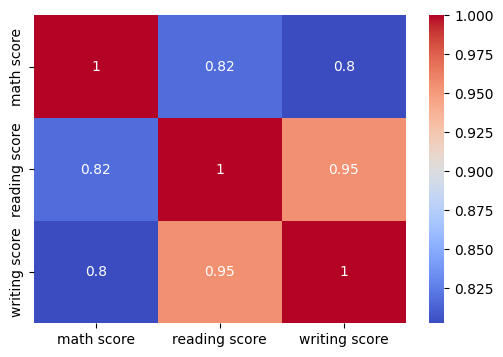

In [12]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(6,4))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.show()

## Exploratory Data Analysis Observations

1. Reading and writing scores show a strong positive correlation with mathematics scores.
2. Students who completed the test preparation course generally achieved higher scores.
3. Students receiving standard lunch performed better than students receiving free/reduced lunch.
4. Male students scored slightly higher in mathematics on average.

In [13]:
X = df.drop("math score", axis=1)
y = df["math score"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
cat_cols = X.select_dtypes(include="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ],
    remainder="passthrough"
)

In [16]:
lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [17]:
pred_lr = lr_model.predict(X_test)

In [18]:
print("MAE:", mean_absolute_error(y_test, pred_lr))
print("R2 Score:", r2_score(y_test, pred_lr))

MAE: 4.214763142474852
R2 Score: 0.8804332983749564


In [19]:
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

dt_model.fit(X_train, y_train)

pred_dt = dt_model.predict(X_test)

print("Decision Tree R2:",
      r2_score(y_test, pred_dt))

Decision Tree R2: 0.7313412104295911


In [20]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

pred_rf = rf_model.predict(X_test)

print("Random Forest R2:",
      r2_score(y_test, pred_rf))

Random Forest R2: 0.8488482534120778


In [21]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "R2 Score":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_dt),
        r2_score(y_test,pred_rf)
    ]
})

results.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,R2 Score
0,Linear Regression,0.880433
2,Random Forest,0.848848
1,Decision Tree,0.731341


## Conclusion

The project successfully predicted student mathematics performance using machine learning techniques. Among the models tested, Linear Regression performed best with an R² score of 0.8804. The analysis showed that reading scores, writing scores, test preparation, lunch type, and parental education significantly influence student performance.